# 03 — Modelagem

**Dimensão 5 da rubrica — 20 pontos.** São comparados dois classificadores: Regressão Logística e Random Forest.

## Navegação
- [1. Carregamento e divisão](#model-divisao)
- [2. Seleção dos modelos](#model-selecao)
- [3. Regressão Logística](#model-logistica)
- [4. Random Forest](#model-rf)
- [5. Validação cruzada](#model-cv)
- [6. Comparação](#model-comparacao)
- [7. Salvamento dos artefatos](#model-artefatos)

<a id="model-divisao"></a>
## 1. Carregamento e divisão dos dados

O código carrega dataset_tratado.csv, separa TARGET das variáveis preditoras, remove identificadores disponíveis e cria conjuntos de treino e teste com divisão estratificada.

In [15]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# 1. Definir o caminho e carregar o ficheiro processado de forma segura
PROCESSED = Path("../data/processed")
file_path = PROCESSED / "dataset_tratado.csv"

df = pd.read_csv(file_path)
print(f"Dimensão do dataset carregado: {df.shape}")

# 2. Separar as variáveis preditoras (X) da variável alvo (y)
# Garantimos a remoção de colunas de identificação que não possuem poder preditivo
cols_to_drop = [col for col in ['TARGET', 'ID', 'Unnamed: 0'] if col in df.columns]
X = df.drop(columns=cols_to_drop) 
y = df['TARGET']

# 3. Divisão em Treino e Teste (Train-Test Split com estratificação rigorosa)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,      
    random_state=42,     
    stratify=y           
)

print(f"\nDimensão dos dados de Treino (X_train): {X_train.shape}")
print(f"Dimensão dos dados de Teste (X_test): {X_test.shape}")

# Validar se a estratificação funcionou perfeitamente
print(f"\nProporção de inadimplência no Treino:\n{(y_train.value_counts(normalize=True) * 100).round(2)}")
print(f"Proporção de inadimplência no Teste:\n{(y_test.value_counts(normalize=True) * 100).round(2)}")

Dimensão do dataset carregado: (36457, 50)

Dimensão dos dados de Treino (X_train): (25519, 48)
Dimensão dos dados de Teste (X_test): (10938, 48)

Proporção de inadimplência no Treino:
TARGET
0    98.31
1     1.69
Name: proportion, dtype: float64
Proporção de inadimplência no Teste:
TARGET
0    98.31
1     1.69
Name: proportion, dtype: float64


**Explicação e leitura dos resultados:** A base possui 36.457 linhas e 50 colunas. Após separar o alvo e remover colunas não preditoras, o treino contém 25.519 registros e 48 features; o teste contém 10.938 registros e as mesmas 48 features. Com test_size=0.30, random_state=42 e stratify=y, as proporções observadas são 98,31% da classe 0 e 1,69% da classe 1 em ambos os conjuntos, arredondadas a duas casas. A estratificação preserva aproximadamente a proporção das classes; não garante ausência de outras formas de viés.

<a id="model-selecao"></a>
## 2. Seleção dos modelos

### 2.1 Características do problema que orientam a escolha

A população de modelagem tem 36.457 registros e 48 variáveis preditoras após remover o alvo e identificadores. É uma tarefa de classificação binária em dados tabulares, com forte desbalanceamento: 35.841 bons pagadores (classe 0; 98,31%) e 616 maus pagadores (classe 1; 1,69%). Esse cenário exige avaliar as duas classes e não usar acurácia isoladamente: um modelo que sempre previsse a classe 0 já teria cerca de 98,31% de acurácia, mas não identificaria nenhum mau pagador.

### 2.2 Por que comparar Regressão Logística e Random Forest

A Regressão Logística foi escolhida como referência (baseline) por ser um classificador linear amplamente usado em problemas binários, relativamente simples de treinar e interpretar em comparação com modelos mais complexos. O escalonamento das variáveis numéricas é incluído no pipeline porque a escala pode afetar o ajuste desse modelo. Ela permite estabelecer uma referência para saber se um modelo mais flexível melhora o desempenho; não se presume que seja a melhor solução.

O Random Forest foi escolhido como contraponto não linear: combina várias árvores de decisão e pode representar relações e interações entre variáveis que um classificador linear não captura diretamente. É adequado como candidato para dados tabulares e não exige que as variáveis estejam em escalas comparáveis. Neste experimento, ambos os classificadores usam `class_weight='balanced'` para dar mais peso à classe minoritária durante o treinamento; isso não garante bons resultados para essa classe e precisa ser confirmado pelas métricas.

Assim, os dois modelos formam uma comparação didática e tecnicamente razoável entre uma referência linear e um método de árvores, com complexidade e comportamento distintos. Não são os únicos modelos adequados a esse tipo de dado. Árvores de Gradient Boosting (por exemplo, HistGradientBoosting, XGBoost ou LightGBM), árvores simples e outros classificadores também poderiam ser avaliados, mas não foram treinados neste projeto.

### 2.3 O que a comparação permite concluir

Como apenas Regressão Logística e Random Forest foram comparados, não há evidência para afirmar que sejam os melhores modelos possíveis para esta base. Para isso, seria necessário testar candidatos adicionais, ajustar hiperparâmetros sem usar o conjunto de teste para seleção e comparar todos com o mesmo protocolo de validação. A escolha entre os dois atuais segue a prioridade de negócio definida: reduzir bons pagadores (classe 0) classificados como maus pagadores (classe 1). Portanto, o critério principal é o recall/especificidade da classe 0; o recall da classe 1 mostra quantos maus pagadores são identificados e evidencia a troca entre os dois tipos de erro. ROC-AUC, precisão e F1 complementam a leitura, mas não definem sozinhos se um modelo está adequado para uso real.

Não foi estabelecido um limite mínimo de aceitação nem foram quantificados os custos financeiros dos erros. Além disso, o alvo é retrospectivo e a avaliação usa uma única divisão treino/teste e validação cruzada aleatória, não uma validação temporal ou externa. Os resultados servem para comparar candidatos neste experimento, não para aprovar o uso operacional. A importância de variáveis do Random Forest não é explicação causal nem justificativa regulatória individual.

<a id="model-logistica"></a>
## 3. Regressão Logística

### 3.1 Treinamento e avaliação

A Regressão Logística é usada como referência (baseline). StandardScaler é ajustado somente com X_train; os dados de teste são transformados com o escalonador já ajustado. O classificador usa class_weight='balanced' para ponderar as classes durante o ajuste.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# O pipeline mantém o escalonamento dentro do treino e da validação cruzada.
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=42,
        max_iter=5000,
        class_weight='balanced',
        solver='lbfgs'
    ))
])

pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)
y_proba = pipeline_lr.predict_proba(X_test)[:, 1]

matriz_lr = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn_lr, fp_lr, fn_lr, tp_lr = matriz_lr.ravel()
recall_bons_pagadores_lr = tn_lr / (tn_lr + fp_lr)
taxa_falsos_positivos_lr = fp_lr / (tn_lr + fp_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba)

print("Matriz de confusão (Regressão Logística; linhas=real, colunas=previsto):")
print(matriz_lr)
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))
print(f"Recall dos bons pagadores / especificidade: {recall_bons_pagadores_lr:.4f}")
print(f"Taxa de bons pagadores classificados como maus / taxa de falsos positivos: {taxa_falsos_positivos_lr:.4f}")
print(f"ROC-AUC: {roc_auc_lr:.4f}")

Matriz de confusão (Regressão Logística; linhas=real, colunas=previsto):
[[6549 4204]
 [  99   86]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.9851    0.6090    0.7527     10753
           1     0.0200    0.4649    0.0384       185

    accuracy                         0.6066     10938
   macro avg     0.5026    0.5370    0.3956     10938
weighted avg     0.9688    0.6066    0.7406     10938

Recall dos bons pagadores / especificidade: 0.6090
Taxa de bons pagadores classificados como maus / taxa de falsos positivos: 0.3910
ROC-AUC: 0.5608


### 3.1.1 Leitura dos resultados

A matriz de confusão é [[6549, 4204], [99, 86]]: entre 10.753 bons pagadores (classe 0), 6.549 são identificados corretamente e 4.204 são classificados incorretamente como maus pagadores. A especificidade/recall da classe 0 é 60,90%, equivalente a uma taxa de falsos positivos de 39,10%. Entre 185 maus pagadores (classe 1), 86 são identificados (recall de 46,49%) e 99 não são identificados.

No conjunto de teste e com o limiar padrão de classificação, a Regressão Logística preserva menos bons pagadores do que o Random Forest, mas identifica uma parcela maior dos maus pagadores. Essa troca entre tipos de erro deve ser interpretada com o critério de negócio definido e confirmada pela validação cruzada.

### 3.2 Visualização dos resultados da Regressão Logística

O gráfico apresenta a matriz de confusão e a curva ROC do modelo no conjunto de teste.

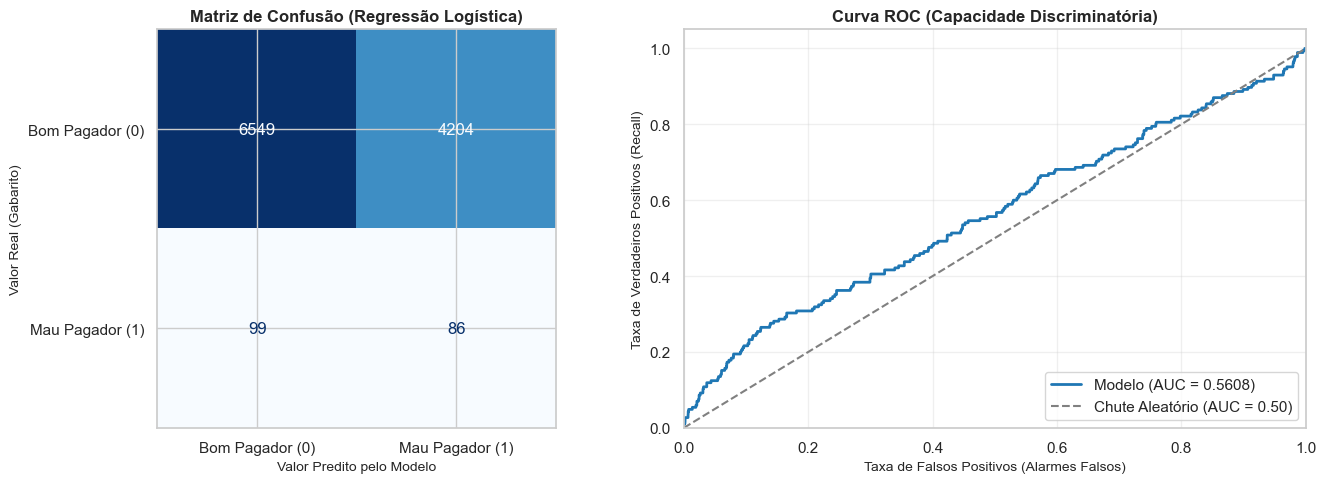

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# Configurar a área dos gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico da Matriz de Confusão (Heatmap)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    cmap='Blues', 
    ax=axes[0],
    colorbar=False,
    display_labels=['Bom Pagador (0)', 'Mau Pagador (1)'],
    values_format='d'
)
axes[0].set_title('Matriz de Confusão (Regressão Logística)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor Predito pelo Modelo', fontsize=10)
axes[0].set_ylabel('Valor Real (Gabarito)', fontsize=10)

# 2. Gráfico da Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'Modelo (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Chute Aleatório (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (Alarmes Falsos)', fontsize=10)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=10)
axes[1].set_title('Curva ROC (Capacidade Discriminatória)', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Leitura dos gráficos:** A matriz apresenta 6.549 verdadeiros negativos, 4.204 falsos positivos, 99 falsos negativos e 86 verdadeiros positivos. Os números correspondem à saída da célula de treinamento. A curva ROC apresenta AUC de 0,5608, indicando discriminação limitada nesta amostra.

<a id="model-rf"></a>
## 4. Random Forest

O Random Forest combina árvores e permite capturar relações não lineares. O código ajusta um pipeline com StandardScaler e RandomForestClassifier; o escalonador está encapsulado no pipeline, mas não é necessário para árvores. O classificador usa class_weight='balanced'.

Matriz de confusão (Random Forest; linhas=real, colunas=previsto):
[[10451   302]
 [  129    56]]

Relatório de Classificação (Random Forest):
              precision    recall  f1-score   support

           0     0.9878    0.9719    0.9798     10753
           1     0.1564    0.3027    0.2063       185

    accuracy                         0.9606     10938
   macro avg     0.5721    0.6373    0.5930     10938
weighted avg     0.9737    0.9606    0.9667     10938

Recall dos bons pagadores / especificidade: 0.9719
Taxa de bons pagadores classificados como maus / taxa de falsos positivos: 0.0281

ROC-AUC Score (Random Forest): 0.6681
PR-AUC Score (Random Forest): 0.1045


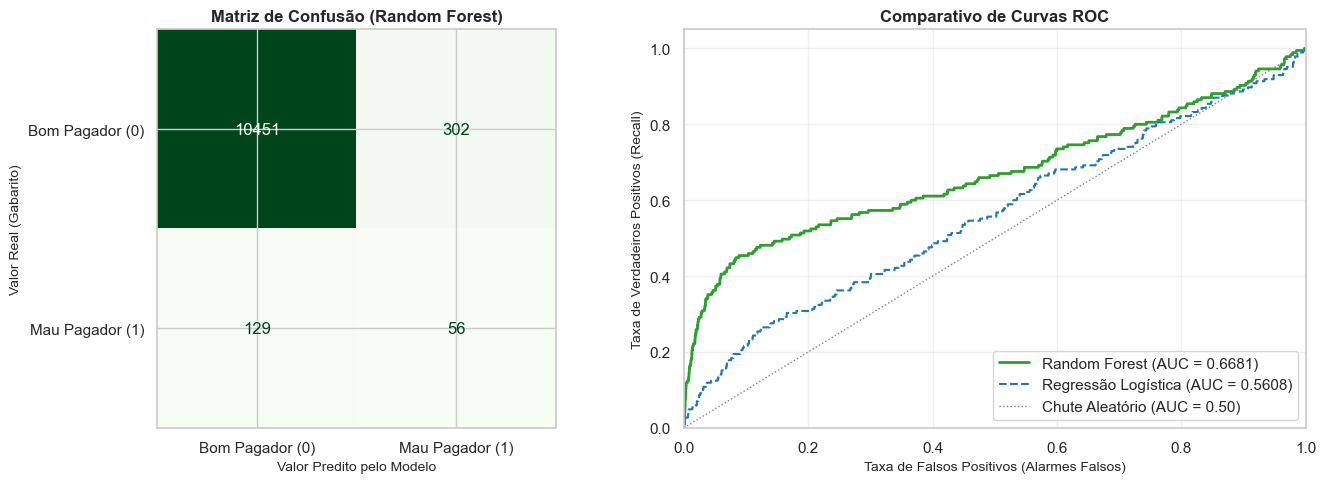

In [18]:
# Random Forest (Floresta Aleatória) com Pipeline e Gráficos Comparativos
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Construir o Pipeline unindo o escalonamento e o Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Treinar o Pipeline exclusivamente com os dados de treino
pipeline_rf.fit(X_train, y_train)

# 3. Gerar previsões na base de teste isolada
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1] # Probabilidade de ser mau pagador

# 4. Avaliar o desempenho do Random Forest
matriz_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
tn_rf, fp_rf, fn_rf, tp_rf = matriz_rf.ravel()
recall_bons_pagadores_rf = tn_rf / (tn_rf + fp_rf)
taxa_falsos_positivos_rf = fp_rf / (tn_rf + fp_rf)
print("Matriz de confusão (Random Forest; linhas=real, colunas=previsto):")
print(matriz_rf)
print("\nRelatório de Classificação (Random Forest):")
print(classification_report(y_test, y_pred_rf, digits=4))
print(f"Recall dos bons pagadores / especificidade: {recall_bons_pagadores_rf:.4f}")
print(f"Taxa de bons pagadores classificados como maus / taxa de falsos positivos: {taxa_falsos_positivos_rf:.4f}")

# Cálculo das métricas
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

print(f"\nROC-AUC Score (Random Forest): {roc_auc_rf:.4f}")
print(f"PR-AUC Score (Random Forest): {pr_auc_rf:.4f}")

# 5. Gerar Gráficos Comparativos (Matriz de Confusão e Curva ROC)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão RF
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, 
    cmap='Greens', 
    ax=axes[0],
    colorbar=False,
    display_labels=['Bom Pagador (0)', 'Mau Pagador (1)'],
    values_format='d'
)
axes[0].set_title('Matriz de Confusão (Random Forest)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor Predito pelo Modelo', fontsize=10)
axes[0].set_ylabel('Valor Real (Gabarito)', fontsize=10)

# Curva ROC RF vs Regressão Logística
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color='#2ca02c', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')

# Reaproveita a curva ROC do baseline calculada anteriormente (assegure-se de que fpr e tpr da reg. logística existam na memória)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr_lr, tpr_lr, color='#1f77b4', lw=1.5, linestyle='--', label=f'Regressão Logística (AUC = {roc_auc_lr:.4f})')

axes[1].plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1, label='Chute Aleatório (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (Alarmes Falsos)', fontsize=10)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=10)
axes[1].set_title('Comparativo de Curvas ROC', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1 Leitura dos resultados do Random Forest

A matriz de confusão é [[10451, 302], [129, 56]]. Entre 10.753 bons pagadores (classe 0), 10.451 são identificados corretamente e 302 são classificados como maus pagadores: especificidade/recall da classe 0 de 97,19% e taxa de falsos positivos de 2,81%. Entre 185 maus pagadores (classe 1), são identificados 56 (recall de 30,27%) e 129 não são identificados. A precisão da classe 1 é 0,1564, o F1-score é 0,2063, a acurácia é 0,9606, a ROC-AUC é 0,6681 e a PR-AUC é 0,1045.

No conjunto de teste e com o limiar padrão, o Random Forest classifica incorretamente menos bons pagadores como maus pagadores do que a Regressão Logística (302 contra 4.204), mas identifica menos maus pagadores (56 contra 86). A acurácia elevada deve ser interpretada com cautela devido ao desbalanceamento. Esses resultados não demonstram prontidão para uso operacional.

### 4.2 Tratamento do desbalanceamento

A classe 1 representa cerca de 1,69% da população de modelagem. Um classificador que previsse todos os registros como classe 0 teria acurácia próxima de 98,31%, mas recall zero para a classe 1. Por esse motivo, os dois classificadores usam class_weight='balanced', que altera os pesos das classes durante o ajuste. A configuração não garante a identificação de todos os inadimplentes nem elimina a necessidade de avaliar precisão, recall e custos de decisão. Não são aplicados SMOTE nem undersampling.

<a id="model-cv"></a>
## 5. Validação cruzada

A validação estratificada divide os dados de treino em cinco partições e preserva aproximadamente a proporção das classes. As métricas são calculadas nas partições de validação; a análise complementa o teste retido, mas não comprova desempenho em populações futuras. O escalonamento e o ajuste de cada modelo são executados dentro de cada partição pelo pipeline, evitando que a validação use estatísticas calculadas em seus próprios registros.

In [19]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score
import pandas as pd
import numpy as np

# Cinco partições estratificadas para comparar os modelos apenas no treino.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# O recall da classe 0 é a métrica principal; as métricas da classe 1 mostram o compromisso.
scoring = {
    'recall_bons_pagadores': make_scorer(recall_score, pos_label=0),
    'recall_maus_pagadores': make_scorer(recall_score, pos_label=1),
    'precision_maus_pagadores': make_scorer(precision_score, pos_label=1, zero_division=0),
    'f1_maus_pagadores': 'f1',
    'roc_auc': 'roc_auc'
}

resultados_cv = {}
for nome_modelo, pipeline in [
    ('Regressão Logística', pipeline_lr),
    ('Random Forest', pipeline_rf)
]:
    print(f"Executando validação cruzada para {nome_modelo}...")
    resultados_cv[nome_modelo] = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=False
    )

def compilar_resultados_cv(resultados_dict):
    linhas = []
    for nome_modelo, cv_results in resultados_dict.items():
        recall_bons = cv_results['test_recall_bons_pagadores']
        linhas.append({
            'Modelo': nome_modelo,
            'Recall bons pagadores (média)': np.mean(recall_bons),
            'Recall bons pagadores (desvio padrão)': np.std(recall_bons),
            'Taxa de falsos positivos (média)': 1 - np.mean(recall_bons),
            'Recall maus pagadores (média)': np.mean(cv_results['test_recall_maus_pagadores']),
            'Precisão maus pagadores (média)': np.mean(cv_results['test_precision_maus_pagadores']),
            'F1 maus pagadores (média)': np.mean(cv_results['test_f1_maus_pagadores']),
            'ROC-AUC (média)': np.mean(cv_results['test_roc_auc']),
            'ROC-AUC (desvio padrão)': np.std(cv_results['test_roc_auc'])
        })
    return pd.DataFrame(linhas)

df_resultados_cv = compilar_resultados_cv(resultados_cv)
display(df_resultados_cv)

Executando validação cruzada para Regressão Logística...
Executando validação cruzada para Random Forest...


,Modelo,Recall bons pagadores (média),Recall bons pagadores (desvio padrão),Taxa de falsos positivos (média),Recall maus pagadores (média),Precisão maus pagadores (média),F1 maus pagadores (média),ROC-AUC (média),ROC-AUC (desvio padrão)
0,Regressão Logística,0.606744,0.006752,0.393256,0.505827,0.021602,0.041434,0.583558,0.026157
1,Random Forest,0.975207,0.002474,0.024793,0.338679,0.190876,0.243733,0.712821,0.042050


**Como interpretar a tabela:** compare primeiro o recall médio dos bons pagadores: valores maiores significam menor proporção de bons pagadores incorretamente classificados como maus pagadores; a taxa de falsos positivos expressa o mesmo objetivo em sentido inverso. Em seguida, observe o recall dos maus pagadores para entender quantos casos de risco deixam de ser identificados, além da precisão, F1 e ROC-AUC.

A tabela é recalculada ao executar a célula. A escolha prioriza o recall da classe 0, mas não prova que o modelo seja adequado para concessão real: não há limite mínimo de aceitação nem custos de erro definidos. Os parâmetros do Random Forest são n_estimators=200, max_depth=12 e class_weight='balanced'; não foi realizada busca sistemática para otimizá-los.

<a id="model-comparacao"></a>
## 6. Comparação dos modelos

O gráfico compara, na validação cruzada, o recall dos bons pagadores (métrica prioritária), o recall dos maus pagadores e a ROC-AUC. A leitura conjunta deixa visível o compromisso entre evitar falsos positivos e identificar a classe de risco.

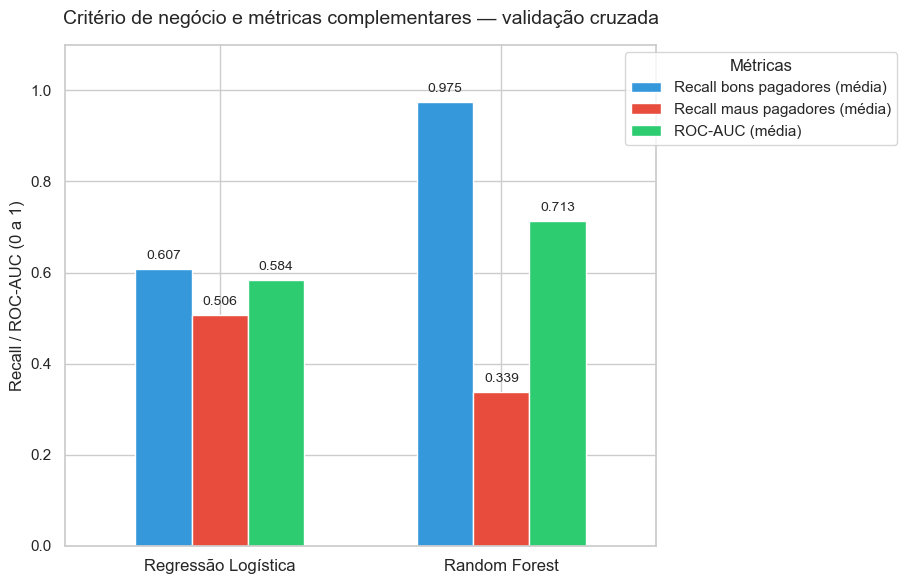

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparando os dados para o gráfico usando o DataFrame gerado na etapa 3.4
df_plot = df_resultados_cv[[
    'Modelo',
    'Recall bons pagadores (média)',
    'Recall maus pagadores (média)',
    'ROC-AUC (média)'
]].set_index('Modelo')

# Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")
cores = ['#3498db', '#e74c3c', '#2ecc71']

# Criando o gráfico de barras
ax = df_plot.plot(kind='bar', figsize=(10, 6), color=cores, width=0.6)

# Customizando títulos e eixos
plt.title('Critério de negócio e métricas complementares — validação cruzada', fontsize=14, pad=15)
plt.ylabel('Recall / ROC-AUC (0 a 1)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=0, fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Métricas', loc='upper right', bbox_to_anchor=(1.42, 1))

# Adicionando os valores numéricos no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Evita tentar anotar valores zerados
        ax.annotate(f'{altura:.3f}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

**Leitura do gráfico:** use o recall dos bons pagadores para comparar o objetivo prioritário; um valor maior corresponde a menos bons pagadores encaminhados incorretamente como maus pagadores. O recall dos maus pagadores informa o custo paralelo dessa escolha: casos de risco que o modelo deixa passar. A ROC-AUC resume a capacidade de ordenar as classes em vários limiares, mas não mede diretamente o resultado no limiar padrão. Consulte a tabela da validação cruzada para as taxas e dispersões exatas; não conclua que o modelo é bom apenas por uma métrica.

<a id="model-artefatos"></a>
## 7. Salvamento dos artefatos

A célula seguinte salva as partições de teste e o pipeline do Random Forest para uso na avaliação. São artefatos intermediários gerados pelo código, não dados versionados.

In [21]:
import joblib
from pathlib import Path

# Garantindo que a pasta processed existe
caminho_processed = Path("../data/processed")
caminho_processed.mkdir(parents=True, exist_ok=True)

# Salvando os dados de teste em CSV
X_test.to_csv(caminho_processed / "X_test.csv", index=False)
y_test.to_csv(caminho_processed / "y_test.csv", index=False)

# Salvando o pipeline completo (scaler + modelo) para garantir consistência em produção
joblib.dump(pipeline_rf, caminho_processed / "modelo_rf_vencedor.pkl")

print("Pipeline do Random Forest guardado com sucesso para a pasta 'processed'!")

Pipeline do Random Forest guardado com sucesso para a pasta 'processed'!


**Explicação do salvamento:** O código cria o diretório de dados processados, grava X_test.csv e y_test.csv sem índices e persiste o pipeline em modelo_rf_vencedor.pkl. A mensagem de saída confirma o salvamento do pipeline. Esses artefatos permitem que o Notebook 04 avalie o mesmo modelo e a mesma amostra de teste sem refazer o treinamento nessa etapa. 

<a id="model-conclusao"></a>
## 8. Conclusão da modelagem

Neste notebook, a base de modelagem foi dividida em treino e teste de forma estratificada; foram treinados e comparados dois modelos, Regressão Logística e Random Forest. A validação cruzada estratificada em cinco partições compara os modelos sem usar o conjunto de teste para o ajuste. O pipeline Random Forest e a partição de teste são salvos para a avaliação no Notebook 04.

No conjunto de teste, com o limiar padrão, a Regressão Logística classificou corretamente 6.549 dos 10.753 bons pagadores e classificou incorretamente 4.204 deles como maus pagadores (especificidade de 60,90%). Identificou 86 dos 185 maus pagadores (recall de 46,49%). O Random Forest classificou corretamente 10.451 bons pagadores e classificou incorretamente 302 como maus pagadores (especificidade de 97,19%); identificou 56 dos 185 maus pagadores (recall de 30,27%).

Assim, pelos resultados desse teste e pela prioridade estabelecida de evitar classificar bons pagadores como maus, o Random Forest apresenta o menor número de falsos positivos entre os dois modelos avaliados. A contrapartida é que deixa passar mais maus pagadores: 129, contra 99 na Regressão Logística. Esta é uma comparação entre apenas dois modelos; não demonstra que o Random Forest seja o melhor modelo possível nem que esteja pronto para uso operacional. O alvo retrospectivo, o desbalanceamento da classe 1 e a ausência de avaliação temporal/externa e de custos financeiros quantificados limitam as conclusões.

**Importante:** a tabela e o gráfico da validação cruzada usam agora métricas atualizadas para ambas as classes. Execute as células do notebook em ordem para atualizar essas saídas antes de registrar ou apresentar os resultados; saídas salvas de execuções anteriores podem refletir métricas antigas.

### Guia rápido das métricas

- **Recall da classe 0 / especificidade:** proporção de bons pagadores corretamente identificados; sua queda equivale a mais bons pagadores classificados como maus.
- **Recall da classe 1:** proporção de maus pagadores corretamente identificados; valores baixos significam mais casos de risco não detectados.
- **Precisão da classe 1:** entre os casos classificados como maus pagadores, proporção que realmente pertence à classe 1.
- **F1-score:** média harmônica entre precisão e recall de uma classe; resume o equilíbrio entre essas duas medidas.
- **Acurácia:** proporção total de classificações corretas; precisa ser interpretada com cautela quando as classes são desbalanceadas.
- **ROC-AUC:** capacidade de ordenar casos das duas classes ao longo de diferentes limiares; não escolhe o limiar nem substitui a métrica prioritária.
- **Matriz de confusão:** contagem de previsões corretas e incorretas por classe, incluindo verdadeiros e falsos positivos/negativos.